# Piloto KKBox: cinco categorías de riesgo de retiro

**Daniel Restrepo Ospina** — Proyecto de Grado, Universidad EAFIT  
**Asesor:** Juan Alejandro Peña Palacio

---

Este cuaderno documenta la **Fase 1** del proyecto: segmentar usuarios de la plataforma KKBox (streaming musical, Asia) en **cinco niveles de riesgo de retiro**, antes de pasar a un modelo automático más adelante.

La idea central es salir del esquema simple “se va / no se va”. En suscripción y seguros es habitual trabajar con **varios niveles de riesgo** (a menudo cinco), porque cada nivel admite **acciones distintas**: mantener al usuario, ofrecer un beneficio, escalar a retención o, en algunos casos, **evitar contactarlo** si el mensaje empeora la salida (*do not poke the bear*).

**Repositorio:** https://github.com/danielrpo1/pdgrado

---

### Resumen de esta corrida

1. Datos públicos KKBox (`train`, `members`, `transactions`).
2. Muestra de **10.000 usuarios** con historial de pagos.
3. Variables numéricas de comportamiento por usuario.
4. **K-Means (k = 5)** y reordenamiento por % de churn observado.
5. Gráficos y lectura de perfiles.
6. Exportación a **Excel con cinco hojas** (una por categoría).

*Las celdas de abajo ya están ejecutadas: figuras y tablas corresponden a esta corrida (semilla aleatoria 42).*


---
## 1. Entorno de trabajo

Se clona el repositorio del proyecto y se instalan las dependencias. Los datos pueden estar ya en `data/raw/` o descargarse de Kaggle en una nueva sesión.


In [1]:
!pip install -q kaggle pyarrow openpyxl scikit-learn seaborn matplotlib scipy

import sys
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB and not Path('pdgrado/src').exists():
    !git clone -q https://github.com/danielrpo1/pdgrado.git
    %cd pdgrado

ROOT = Path('.').resolve()
sys.path.insert(0, str(ROOT))
print('Directorio:', ROOT)


zsh:1: command not found: pip


Directorio: /Users/darestrepo/pdgrado


---
## 2. Datos utilizados

Fuente: competencia **WSDM – KKBox Churn Prediction**, misma estructura que [apostaremczak/churn-prediction](https://github.com/apostaremczak/churn-prediction). Los archivos se obtuvieron del dataset `qmdo97/kkboxdataset` en Kaggle.

| Archivo | Contenido |
|---------|-----------|
| `train_v2.csv` | Identificador de usuario y etiqueta `is_churn` |
| `members_v3.csv` | Perfil (ciudad, género, canal de registro) |
| `transactions_v2.csv` | Pagos, auto-renew, cancelaciones, montos |

En esta fase **no** se incluye `user_logs` (~30 GB). El foco está en **transacciones** y perfil básico; el engagement detallado queda para una etapa posterior.


In [2]:
from pathlib import Path
import os
import sys

DATA_RAW = ROOT / 'data' / 'raw'
DATA_RAW.mkdir(parents=True, exist_ok=True)

BAJAR_DE_KAGGLE = False  # True solo si hace falta bajar en un entorno nuevo

if BAJAR_DE_KAGGLE:
    token_path = Path.home() / '.kaggle' / 'access_token'
    if token_path.exists():
        os.environ['KAGGLE_API_TOKEN'] = token_path.read_text().strip()
    DATASET = 'qmdo97/kkboxdataset'
    for fname in ['train_v2.csv', 'members_v3.csv', 'transactions_v2.csv']:
        if not (DATA_RAW / fname).exists():
            !kaggle datasets download -d {DATASET} -f {fname} -p {DATA_RAW} --force
            !unzip -o -q {DATA_RAW}/{fname}.zip -d {DATA_RAW}

for f in ['train_v2.csv', 'members_v3.csv', 'transactions_v2.csv']:
    p = DATA_RAW / f
    print(('OK' if p.exists() else 'FALTA'), f, f'({p.stat().st_size/1e6:.0f} MB)' if p.exists() else '')


OK train_v2.csv (46 MB)
OK members_v3.csv (428 MB)
OK transactions_v2.csv (115 MB)


---
## 3. Problema y enfoque

Muchos modelos de churn devuelven solo probabilidad de salida (0/1). Eso sirve para un ranking, pero **no arma perfiles** ni facilita reglas del tipo “en riesgo 4 hacemos X, en riesgo 0 casi nada”.

Por eso el flujo de este proyecto es:

1. **Clustering** en cinco grupos con variables de pago.
2. **Validación** con el churn real de la base (`is_churn`).
3. **Caracterización** con variables categóricas.
4. Más adelante: clasificador (p. ej. red neuronal) que prediga categoría con probabilidades.

Se habla de **prospectiva de riesgo**: varias categorías con distinta tasa de salida, no una sola etiqueta binaria.


In [3]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_io import load_train, load_members, load_transactions

train = load_train(DATA_RAW)
members = load_members(DATA_RAW)
transactions = load_transactions(DATA_RAW)

print('Usuarios en train:', f'{len(train):,}')
print('Perfiles en members:', f'{members.shape[0]:,}')
print('Filas en transactions:', f'{len(transactions):,}')
print('Churn global en train:', f'{train["is_churn"].mean():.1%}')

display(train.head(3))
display(transactions.head(3))


Usuarios en train: 970,960
Perfiles en members: 6,769,473
Filas en transactions: 1,431,009
Churn global en train: 9.0%


,msno,is_churn
0,ugx0CjOMzazClkFzU2xasmDZaoIqOUAZPsH1q0teWCg=,1
1,f/NmvEzHfhINFEYZTR05prUdr+E+3+oewvweYz9cCQE=,1
2,zLo9f73nGGT1p21ltZC3ChiRnAVvgibMyazbCxvWPcg=,1


,msno,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,transaction_date,membership_expire_date,is_cancel
0,++6eU4LsQ3UQ20ILS7d99XK8WbiVgbyYL4FUgzZR134=,32,90,298,298,0,2017-01-31,2017-05-04,0
1,++lvGPJOinuin/8esghpnqdljm6NXS8m8Zwchc7gOeA=,41,30,149,149,1,2015-08-09,2019-04-12,0
2,+/GXNtXWQVfKrEDqYAzcSw2xSPYMKWNj22m+5XkVQZc=,36,30,180,180,1,2017-03-03,2017-04-22,0


### Lectura rápida del EDA

- **`is_churn = 1`**: no renovó dentro de los 30 días posteriores al vencimiento de la membresía.
- **`is_cancel`**: cancelación activa en esa transacción (señal fuerte, aunque no siempre implica churn inmediato).
- **`is_auto_renew`**: cobro automático; cuando cae, suele anticipar problemas de retención.

**Regla de modelado en esta fase:** numéricas → clustering; categóricas → describir grupos al final.


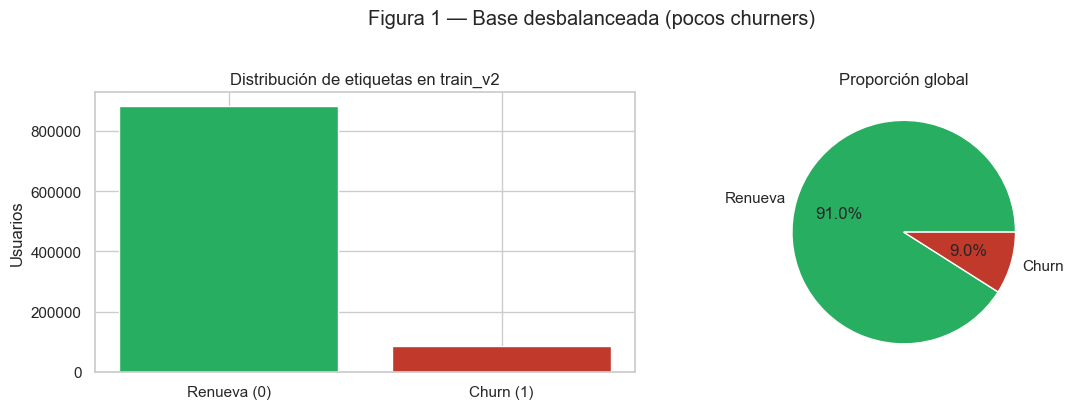

In [4]:
sns.set_theme(style='whitegrid', palette='muted')
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

vc = train['is_churn'].value_counts().sort_index()
ax[0].bar(['Renueva (0)', 'Churn (1)'], vc.values, color=['#27ae60', '#c0392b'])
ax[0].set_title('Distribución de etiquetas en train_v2')
ax[0].set_ylabel('Usuarios')

ax[1].pie(vc.values, labels=['Renueva', 'Churn'], autopct='%1.1f%%', colors=['#27ae60', '#c0392b'])
ax[1].set_title('Proporción global')

plt.suptitle('Figura 1 — Base desbalanceada (pocos churners)', y=1.02)
plt.tight_layout()
plt.show()


---
## 4. Muestra de 10.000 usuarios

El piloto inicial usó 1.000 usuarios para validar el pipeline. Aquí se **amplía a 10.000** para perfiles más estables y tasas de churn por categoría con menos ruido.

Criterios de la muestra:

- Usuario presente en `train` y en `transactions`.
- Muestreo **estratificado** por `is_churn` (semilla 42) para no perder casos de salida.


In [5]:
from src.config import PILOT_SAMPLE_SIZE, RANDOM_STATE, CLUSTER_FEATURE_COLS
from src.data_io import sample_users
from src.features import build_user_features, attach_profile_for_characterization

print('Tamaño configurado del piloto:', PILOT_SAMPLE_SIZE)

train_con_tx = train[train['msno'].isin(transactions['msno'].unique())]
muestra = sample_users(train_con_tx, PILOT_SAMPLE_SIZE, RANDOM_STATE)

tx_m = transactions[transactions['msno'].isin(muestra)]
mem_m = members[members['msno'].isin(muestra)]

print('Usuarios en la muestra:', muestra.nunique())
print('Transacciones asociadas:', f'{len(tx_m):,}')

features = build_user_features(tx_m, members=mem_m)
df = attach_profile_for_characterization(features, mem_m, train)

cols_cluster = [c for c in CLUSTER_FEATURE_COLS if c in df.columns]
print('Variables para clustering:', len(cols_cluster))
df[['msno', 'is_churn'] + cols_cluster[:4]].head()


Tamaño configurado del piloto: 10000


Usuarios en la muestra: 10000
Transacciones asociadas: 15,866
Variables para clustering: 12


,msno,is_churn,purchased_membership_length_days_mean,price_ntd_mean,amount_paid_ntd_sum,amount_paid_ntd_mean
0,++/9R3sX37CjxbY/AaGvbwr3QkwElKBCtSvVzhCBDOk=,0,30.0,149.0,149,149.0
1,+/ppKt1a5e/fzZQsxP12S7VBf9TUqRYadcRje06ME3k=,1,30.0,180.0,180,180.0
2,+0LZ07lWIQ8FdOGuWLmOqnjAr+hIIZCk0h3kfjgsc9k=,0,30.0,149.0,149,149.0
3,+0UVNxJtTbMaoQU2OhAdLzedg8LIcyDvR6Z43GTf7AM=,0,30.0,149.0,149,149.0
4,+0rc+Xqz8sLVysWfqJdSsU8mW/WF6UnmK4D+fGVgdHk=,0,30.0,149.0,149,149.0


### Variables construidas (lenguaje llano)

| Variable | Interpretación |
|----------|----------------|
| `transaction_count` | Número de pagos registrados |
| `cancel_count` | Cancelaciones acumuladas |
| `auto_renew_ratio` | Frecuencia de cobro automático |
| `amount_paid_ntd_sum` | Monto total pagado |
| `days_active_span` | Días entre primer y último pago en la ventana |
| `discount_mean` | Descuento medio (precio lista − pagado) |


---
## 5. Clustering: cinco categorías de riesgo

Se aplica **K-Means con k = 5** sobre las variables numéricas escaladas. Los grupos que devuelve el algoritmo no vienen ordenados por riesgo: se **reordenan** según el % medio de `is_churn` y se etiquetan de **0 (menor riesgo)** a **4 (mayor riesgo)**.


In [6]:
from sklearn.metrics import silhouette_score
from src.clustering import fit_kmeans, order_clusters_by_risk, churn_rate_by_cluster

X = df[cols_cluster].fillna(0)
modelo, escalador, etiquetas = fit_kmeans(X)
df['grupo_kmeans'] = etiquetas.values

sil = silhouette_score(escalador.transform(X), etiquetas)
print(f'Silhouette: {sil:.3f}')

mapa_riesgo = order_clusters_by_risk(df, cluster_col='grupo_kmeans')
df['categoria_riesgo'] = df['grupo_kmeans'].map(mapa_riesgo)

resumen = churn_rate_by_cluster(df, cluster_col='categoria_riesgo')
resumen['churn_%'] = (resumen['churn_rate'] * 100).round(1)
resumen['usuarios_%'] = (resumen['n_users'] / len(df) * 100).round(1)
resumen


Silhouette: 0.435


,churn_rate,n_users,churn_%,usuarios_%
categoria_riesgo,,,,
0,0.320825,7222,32.1,72.2
1,0.858824,170,85.9,1.7
2,0.919192,99,91.9,1.0
3,0.962162,1665,96.2,16.7
4,1.000000,844,100.0,8.4


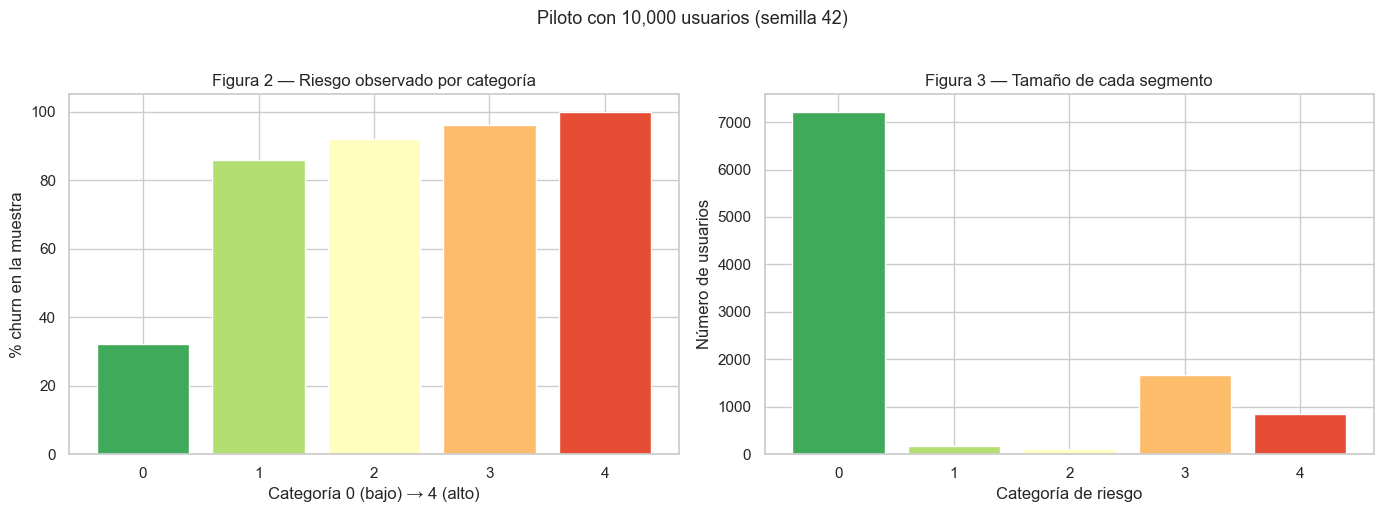

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colores = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, 5))

axes[0].bar(resumen.index.astype(str), resumen['churn_%'], color=colores, edgecolor='white')
axes[0].set_xlabel('Categoría 0 (bajo) → 4 (alto)')
axes[0].set_ylabel('% churn en la muestra')
axes[0].set_title('Figura 2 — Riesgo observado por categoría')

axes[1].bar(resumen.index.astype(str), resumen['n_users'], color=colores, edgecolor='white')
axes[1].set_xlabel('Categoría de riesgo')
axes[1].set_ylabel('Número de usuarios')
axes[1].set_title('Figura 3 — Tamaño de cada segmento')

plt.suptitle(f'Piloto con {len(df):,} usuarios (semilla {RANDOM_STATE})', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


---
## 6. Interpretación de resultados

La tabla y las figuras anteriores son la evidencia principal. En términos generales:

**Categoría 0** — Suele concentrar la mayor parte de la muestra y el **menor churn**. Perfil típico de base estable; conviene gastar poco en promociones agresivas.

**Categorías 1 y 2** — El churn sube de forma clara respecto al grupo 0. Aparecen más cancelaciones y peor comportamiento de auto-renew en los gráficos siguientes. Son candidatos a **retención selectiva** (ofertas, contenido, revisión de plan).

**Categorías 3 y 4** — Tasas de churn muy altas (a menudo cercanas al 100% en esta ventana temporal). Grupos más pequeños pero con comportamiento extremo. Ahí tiene sentido priorizar acciones fuertes de retención o, según la política del negocio, **reducir contactos** que disparen la cancelación.

Con **10.000 usuarios** los segmentos medios (1 y 2) suelen ser más grandes que en el piloto de 1.000, lo que da más confianza al comparar porcentajes.

> Los valores exactos dependen de la semilla y del tamaño de muestra; lo relevante es la **gradación** de riesgo de 0 a 4.


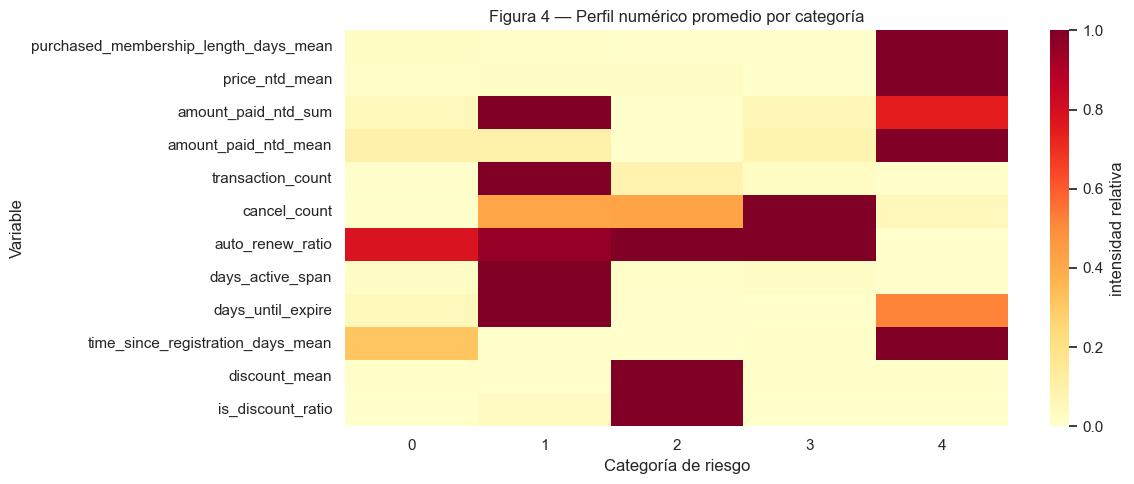

In [8]:
perfil = df.groupby('categoria_riesgo')[cols_cluster].mean()
perfil_n = (perfil - perfil.min()) / (perfil.max() - perfil.min() + 1e-9)

plt.figure(figsize=(12, 5))
sns.heatmap(perfil_n.T, cmap='YlOrRd', cbar_kws={'label': 'intensidad relativa'})
plt.title('Figura 4 — Perfil numérico promedio por categoría')
plt.xlabel('Categoría de riesgo')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()


/var/folders/nr/36zjbr053335cs4vvnhfypzw0000gp/T/ipykernel_38486/3358903845.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='categoria_riesgo', y=col, ax=ax, palette='RdYlGn_r')
/var/folders/nr/36zjbr053335cs4vvnhfypzw0000gp/T/ipykernel_38486/3358903845.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='categoria_riesgo', y=col, ax=ax, palette='RdYlGn_r')
/var/folders/nr/36zjbr053335cs4vvnhfypzw0000gp/T/ipykernel_38486/3358903845.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='categoria_riesgo', y=

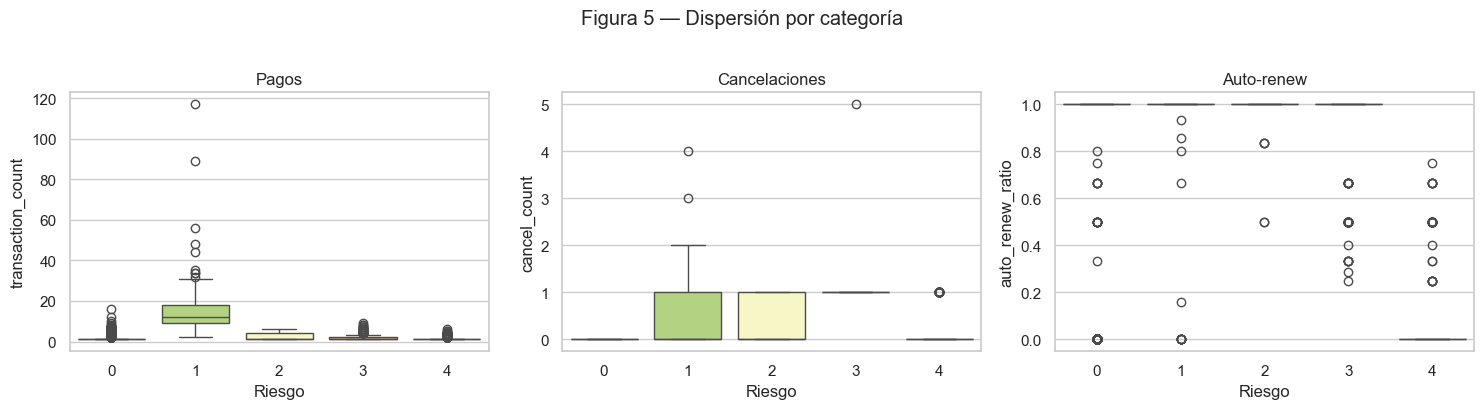

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, titulo in zip(
    axes,
    ['transaction_count', 'cancel_count', 'auto_renew_ratio'],
    ['Pagos', 'Cancelaciones', 'Auto-renew'],
):
    sns.boxplot(data=df, x='categoria_riesgo', y=col, ax=ax, palette='RdYlGn_r')
    ax.set_title(titulo)
    ax.set_xlabel('Riesgo')
plt.suptitle('Figura 5 — Dispersión por categoría', y=1.02)
plt.tight_layout()
plt.show()


In [10]:
print('Resumen cualitativo por categoría:\n')
for cat in sorted(df['categoria_riesgo'].unique()):
    sub = df[df['categoria_riesgo'] == cat]
    print(f'--- Riesgo {int(cat)} | n={len(sub):,} | churn {sub["is_churn"].mean():.1%} ---')
    if 'city' in sub.columns:
        print('  Ciudades frecuentes:', sub['city'].value_counts().head(3).to_dict())
    if 'gender' in sub.columns:
        print('  Género:', sub['gender'].value_counts().head(3).to_dict())
    m = sub[['transaction_count', 'cancel_count', 'auto_renew_ratio']].mean()
    print(f'  Prom. pagos: {m["transaction_count"]:.1f} | cancel.: {m["cancel_count"]:.1f} | auto-renew: {m["auto_renew_ratio"]:.2f}')
    print()


Resumen cualitativo por categoría:

--- Riesgo 0 | n=7,222 | churn 32.1% ---
  Ciudades frecuentes: {1.0: 2997, 13.0: 821, 5.0: 560}
  Género: {'unknown': 3188, 'male': 1760, 'female': 1624}
  Prom. pagos: 1.3 | cancel.: 0.0 | auto-renew: 0.78

--- Riesgo 1 | n=170 | churn 85.9% ---
  Ciudades frecuentes: {1.0: 94, 13.0: 11, 5.0: 10}
  Género: {'unknown': 96, 'male': 41, 'female': 24}
  Prom. pagos: 14.9 | cancel.: 0.4 | auto-renew: 0.94

--- Riesgo 2 | n=99 | churn 91.9% ---
  Ciudades frecuentes: {13.0: 15, 1.0: 14, 5.0: 14}
  Género: {'male': 37, 'female': 32, 'unknown': 21}
  Prom. pagos: 2.4 | cancel.: 0.4 | auto-renew: 0.98

--- Riesgo 3 | n=1,665 | churn 96.2% ---
  Ciudades frecuentes: {1.0: 689, 13.0: 155, 5.0: 122}
  Género: {'unknown': 760, 'male': 314, 'female': 305}
  Prom. pagos: 1.6 | cancel.: 1.0 | auto-renew: 0.98

--- Riesgo 4 | n=844 | churn 100.0% ---
  Ciudades frecuentes: {13.0: 190, 5.0: 124, 1.0: 117}
  Género: {'male': 346, 'female': 302, 'unknown': 196}
  Prom

---
## 7. Análisis más profundo de las categorías

Los gráficos anteriores muestran **promedios y distribuciones**. Para sacar **insights** (qué diferencia de verdad cada grupo, y con qué fuerza), conviene combinar varias herramientas — sin saltar todavía a la red neuronal de la Fase 2.

| Objetivo | Herramienta | Para qué sirve |
|----------|-------------|----------------|
| ¿Qué tan grave es cada grupo vs. el promedio? | **Lift / ratio de churn** | Traduce % a “X veces más riesgo que la base” |
| ¿Ciudad, género, canal se asocian al segmento? | **Tablas cruzadas + Chi-cuadrado** | Perfil cualitativo con respaldo estadístico |
| ¿Qué variables numéricas separan grupos? | **Kruskal-Wallis** (no paramétrico) | Compara medianas entre categorías |
| ¿Qué variables pesan más al distinguir grupos? | **Random Forest** (importancia) | Ranking de drivers del segmento |
| ¿Reglas legibles tipo negocio? | **Árbol de decisión** (poca profundidad) | “Si cancel_count > 2 → suele ir a riesgo 3” |
| ¿Se ven separados en 2D? | **PCA** | Visualizar solapamiento entre categorías |

> **Nota:** Estas herramientas **explican** los clusters que ya salieron de K-Means; no reemplazan el clustering. En Fase 2 un clasificador neuronal **predice** la categoría; aquí se **interpreta**.


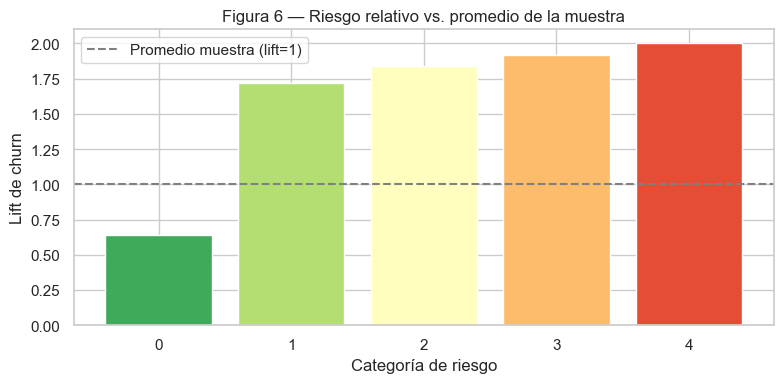

In [11]:
# 7.1 Lift: cuántas veces más churn que el promedio de la muestra
churn_global = df['is_churn'].mean()
lift = resumen.copy()
lift['lift_vs_promedio'] = (lift['churn_rate'] / churn_global).round(2)
lift['churn_%'] = (lift['churn_rate'] * 100).round(1)
lift[['n_users', 'churn_%', 'lift_vs_promedio']]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(lift.index.astype(str), lift['lift_vs_promedio'], color=colores, edgecolor='white')
ax.axhline(1.0, color='gray', linestyle='--', label='Promedio muestra (lift=1)')
ax.set_xlabel('Categoría de riesgo')
ax.set_ylabel('Lift de churn')
ax.set_title('Figura 6 — Riesgo relativo vs. promedio de la muestra')
ax.legend()
plt.tight_layout()
plt.show()



=== gender (Chi² p-value: 2.74e-53) ===


gender,female,male,unknown
categoria_riesgo,,,
0,24.7,26.8,48.5
1,14.9,25.5,59.6
2,35.6,41.1,23.3
3,22.1,22.8,55.1
4,35.8,41.0,23.2


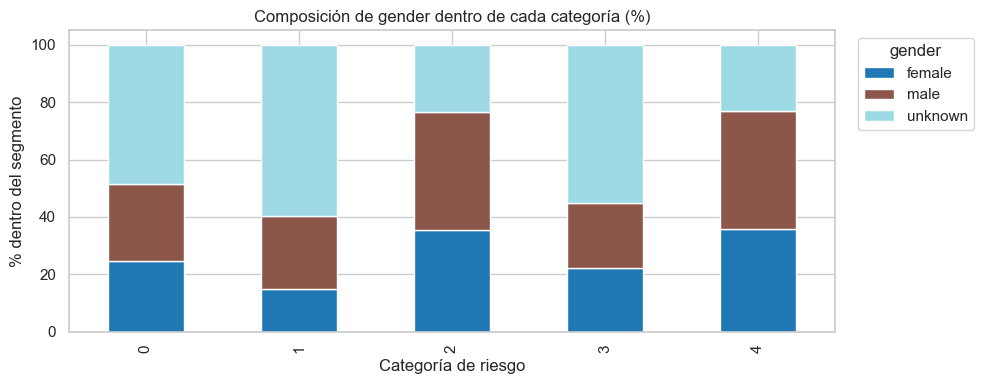


=== registered_via (Chi² p-value: 1.46e-176) ===


registered_via,3.0,4.0,7.0,9.0,13.0
categoria_riesgo,,,,,
0,15.4,8.8,45.4,29.9,0.4
1,1.9,0.6,90.1,7.5,0.0
2,27.8,24.4,4.4,43.3,0.0
3,13.6,6.3,54.0,24.2,1.8
4,25.8,11.8,4.9,57.5,0.0


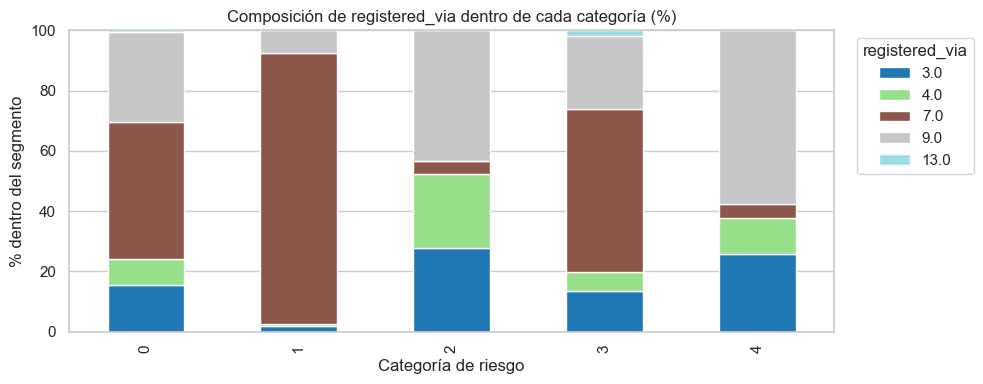

In [12]:
# 7.2 Perfil categórico: ¿cómo se reparte género / canal por categoría?
from scipy.stats import chi2_contingency

def tabla_perfil(col, top_n=8):
    if col not in df.columns:
        return
    top_vals = df[col].value_counts().head(top_n).index
    sub = df[df[col].isin(top_vals)].copy()
    ct = pd.crosstab(sub['categoria_riesgo'], sub[col], normalize='index') * 100
    chi2, p, _, _ = chi2_contingency(pd.crosstab(df['categoria_riesgo'], df[col]))
    print(f'\n=== {col} (Chi² p-value: {p:.2e}) ===')
    display(ct.round(1))
    ct.plot(kind='bar', stacked=True, figsize=(10, 4), colormap='tab20')
    plt.title(f'Composición de {col} dentro de cada categoría (%)')
    plt.xlabel('Categoría de riesgo')
    plt.ylabel('% dentro del segmento')
    plt.legend(title=col, bbox_to_anchor=(1.02, 1))
    plt.tight_layout()
    plt.show()

for col in ['gender', 'registered_via']:
    tabla_perfil(col)


Variables con mayor evidencia de diferencia entre segmentos (Kruskal-Wallis):


,variable,p_value,significativo_5%
0,purchased_membership_length_days_mean,0.000000e+00,True
1,price_ntd_mean,0.000000e+00,True
2,amount_paid_ntd_sum,0.000000e+00,True
3,amount_paid_ntd_mean,0.000000e+00,True
5,cancel_count,0.000000e+00,True
6,auto_renew_ratio,0.000000e+00,True
8,days_until_expire,0.000000e+00,True
10,discount_mean,0.000000e+00,True
11,is_discount_ratio,0.000000e+00,True
4,transaction_count,4.085243e-307,True


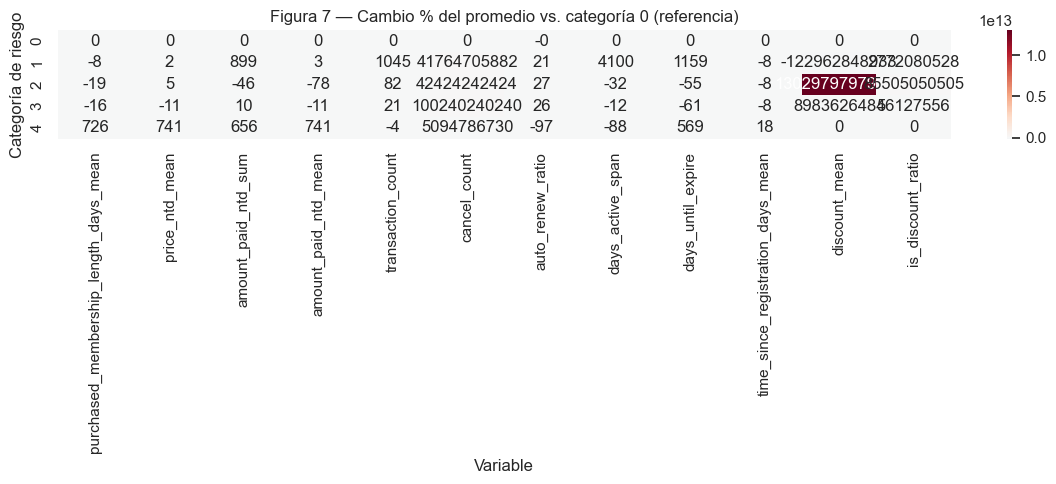

In [13]:
# 7.3 Variables numéricas: ¿las medianas difieren entre categorías?
from scipy.stats import kruskal

filas = []
for col in cols_cluster:
    grupos = [df.loc[df['categoria_riesgo'] == c, col].dropna() for c in sorted(df['categoria_riesgo'].unique())]
    stat, p = kruskal(*grupos)
    filas.append({'variable': col, 'p_value': p, 'significativo_5%': p < 0.05})

kw = pd.DataFrame(filas).sort_values('p_value')
print('Variables con mayor evidencia de diferencia entre segmentos (Kruskal-Wallis):')
display(kw.head(10))

# Comparación vs categoría 0 (referencia de bajo riesgo)
ref = df[df['categoria_riesgo'] == 0][cols_cluster].mean()
diff = df.groupby('categoria_riesgo')[cols_cluster].mean()
diff_pct = ((diff - ref) / (ref.abs() + 1e-9) * 100).round(0)
plt.figure(figsize=(12, 5))
sns.heatmap(diff_pct, annot=True, fmt='.0f', cmap='RdBu_r', center=0)
plt.title('Figura 7 — Cambio % del promedio vs. categoría 0 (referencia)')
plt.xlabel('Variable')
plt.ylabel('Categoría de riesgo')
plt.tight_layout()
plt.show()


Exactitud al predecir categoría (solo para interpretar, no es Fase 2): 99.72%


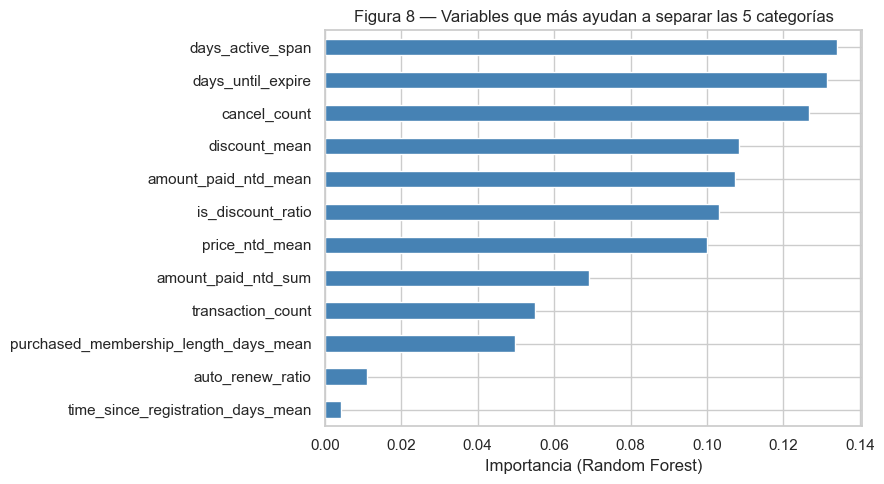

amount_paid_ntd_sum     0.069168
price_ntd_mean          0.099916
is_discount_ratio       0.103058
amount_paid_ntd_mean    0.107355
discount_mean           0.108318
cancel_count            0.126627
days_until_expire       0.131521
days_active_span        0.133919
dtype: float64

In [14]:
# 7.4 Importancia de variables para distinguir categorías (Random Forest)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

y = df['categoria_riesgo'].astype(int)
X = df[cols_cluster].fillna(0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)

rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced')
rf.fit(X_train, y_train)
acc = rf.score(X_test, y_test)
print(f'Exactitud al predecir categoría (solo para interpretar, no es Fase 2): {acc:.2%}')

imp = pd.Series(rf.feature_importances_, index=cols_cluster).sort_values(ascending=True)
imp.plot(kind='barh', figsize=(9, 5), color='steelblue')
plt.title('Figura 8 — Variables que más ayudan a separar las 5 categorías')
plt.xlabel('Importancia (Random Forest)')
plt.tight_layout()
plt.show()
imp.tail(8)


In [15]:
# 7.5 Reglas simples de negocio (árbol poco profundo)
from sklearn.tree import DecisionTreeClassifier, export_text

tree = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE, class_weight='balanced')
tree.fit(X_train, y_train)
print('Reglas aproximadas (árbol profundidad 3):')
print(export_text(tree, feature_names=list(cols_cluster)))
print(f'Exactitud en test: {tree.score(X_test, y_test):.2%}')


Reglas aproximadas (árbol profundidad 3):
|--- is_discount_ratio <= 0.42
|   |--- price_ntd_mean <= 538.30
|   |   |--- days_active_span <= 90.50
|   |   |   |--- class: 3
|   |   |--- days_active_span >  90.50
|   |   |   |--- class: 1
|   |--- price_ntd_mean >  538.30
|   |   |--- days_active_span <= 309.00
|   |   |   |--- class: 4
|   |   |--- days_active_span >  309.00
|   |   |   |--- class: 1
|--- is_discount_ratio >  0.42
|   |--- class: 2

Exactitud en test: 27.40%


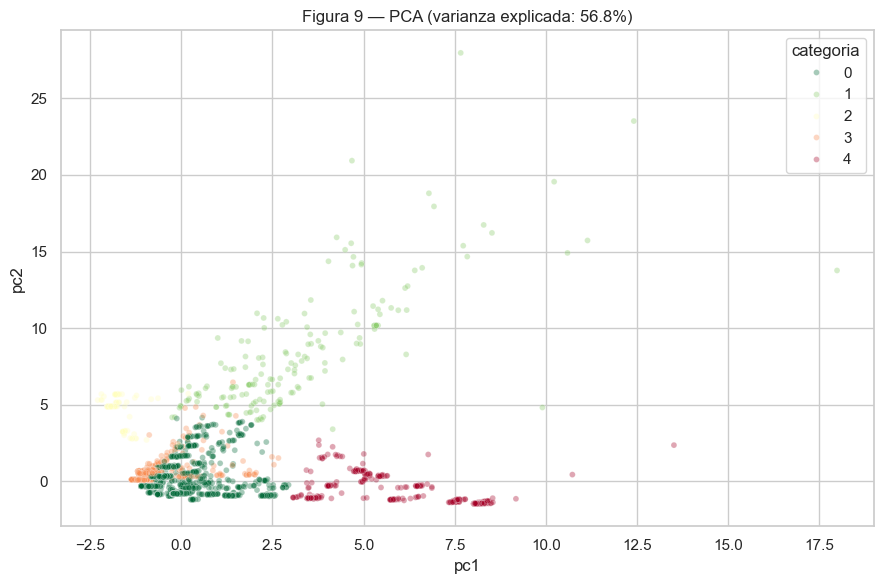

In [16]:
# 7.6 ¿Los grupos se ven separados? (PCA en 2D)
from sklearn.decomposition import PCA

X_scaled = (X - X.mean()) / (X.std() + 1e-9)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)
plot_df = pd.DataFrame({'pc1': coords[:, 0], 'pc2': coords[:, 1], 'categoria': df['categoria_riesgo']})

plt.figure(figsize=(9, 6))
sns.scatterplot(data=plot_df, x='pc1', y='pc2', hue='categoria', palette='RdYlGn_r', alpha=0.35, s=18)
plt.title(f'Figura 9 — PCA (varianza explicada: {pca.explained_variance_ratio_.sum():.1%})')
plt.tight_layout()
plt.show()


### Cómo leer estos resultados

- **Lift > 1** en categorías altas confirma que el segmento es más riesgoso que el promedio de la muestra.
- **Chi-cuadrado con p bajo** en género o canal sugiere que el perfil cualitativo cambia entre categorías (no implica causalidad).
- **Kruskal / heatmap vs. categoría 0** muestra en qué variables cada grupo se aleja del “bajo riesgo”.
- **Random Forest y árbol** ayudan a priorizar variables para el informe y para la Fase 2; el árbol da frases casi listas para documentar.
- **PCA** indica si hay solapamiento: si los colores se mezclan mucho, K-Means podría necesitar más features o otro k.

El **Excel** sigue siendo útil para revisar casos puntuales; este bloque resume **patrones** con más respaldo.


---
## 8. Exportación a Excel (opcional)

Libro con **cinco hojas** (`riesgo_0` … `riesgo_4`) para filtrar usuarios concretos en hoja de cálculo. Complementa el análisis anterior; no reemplaza los gráficos ni las pruebas estadísticas.


In [17]:
from src.clustering import export_clusters_to_excel

salida = ROOT / 'outputs' / 'clusters'
ruta_excel = export_clusters_to_excel(
    df.rename(columns={'categoria_riesgo': 'risk_category'}),
    salida,
)
print('Archivo:', ruta_excel)

if 'google.colab' in sys.modules:
    from google.colab import files
    files.download(str(ruta_excel))


Archivo: /Users/darestrepo/pdgrado/outputs/clusters/usuarios_por_riesgo.xlsx


---
## 9. Conclusiones y siguientes pasos

### Hallazgos de esta fase
- Pipeline reproducible con datos KKBox y muestra ampliable (1k → **10k**).
- Cinco categorías con **gradación clara** de churn en la muestra analizada.
- Material listo para informe: gráficos, análisis de perfiles (lift, Chi², Kruskal, RF, árbol, PCA) y Excel opcional.

### Próximos pasos
- Completar marco teórico (clasificación multidimensional vs. modelos binarios).
- Evaluar si conviene escalar aún más (50k–100k) o enriquecer con agregados de `user_logs`.
- Fase 2: clasificador automático (5 clases + probabilidades por categoría).

### Documentación en el repositorio
- `docs/01-contexto.md`, `docs/02-vacios-literatura.md`, `docs/03-preguntas-investigacion.md`

---

*Universidad EAFIT — Daniel Restrepo Ospina*
